In [ ]:

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
#lpde the saved x_train, x_test, y_train, y_test
import joblib
x_train=joblib.load("../Credit-Card-Fraud-Detection-Analysis-ML/train_test_data/x_train.pkl")
x_test=joblib.load("../Credit-Card-Fraud-Detection-Analysis-ML/train_test_data/x_test.pkl")
y_train=joblib.load("../Credit-Card-Fraud-Detection-Analysis-ML/train_test_data/y_train.pkl")
y_test=joblib.load("../Credit-Card-Fraud-Detection-Analysis-ML/train_test_data/y_test.pkl")
#load the model
loaded_model=joblib.load("../Credit-Card-Fraud-Detection-Analysis-ML/models/best_random_forest_model.pkl")

In [8]:
y_train_pred=loaded_model.predict(x_train)
y_test_pred=loaded_model.predict(x_test)

In [9]:
train_acc=accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_acc:.4f}")

Train Accuracy: 0.9999


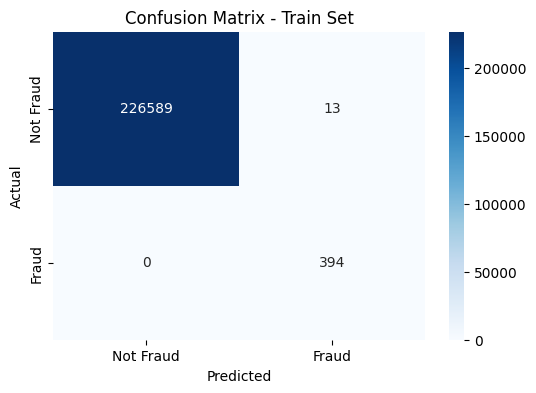

In [13]:
#confution matrix for train set
cm=confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix - Train Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.97      1.00      0.98       394

    accuracy                           1.00    226996
   macro avg       0.98      1.00      0.99    226996
weighted avg       1.00      1.00      1.00    226996



In [7]:

from sklearn.metrics import average_precision_score


train_prob=loaded_model.predict_proba(x_train)[:,1]
print("Train PR AUC Score:",round(average_precision_score(y_train, train_prob), 4))

Train PR AUC Score: 0.9967


In [10]:
test_acc=accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9993


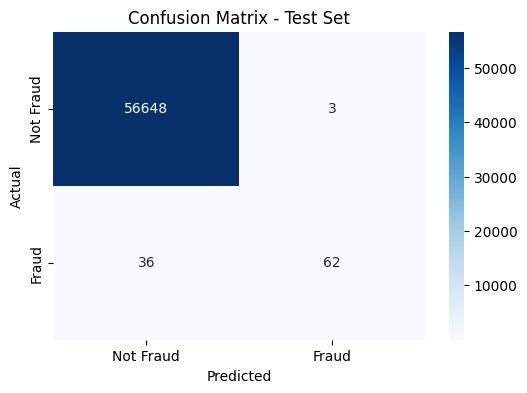

In [11]:
cm=confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues" ,xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
print("Test Classification Report:")
print(classification_report(y_test,y_test_pred))

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.63      0.76        98

    accuracy                           1.00     56749
   macro avg       0.98      0.82      0.88     56749
weighted avg       1.00      1.00      1.00     56749



In [15]:
test_prob=loaded_model.predict_proba(x_test)[:,1]
print("Test PR AUC Score:",round(average_precision_score(y_test, test_prob), 4))

Test PR AUC Score: 0.7531


***Build a predictive system***

In [17]:
def predict_class(input_data):
    input_df=pd.DataFrame(
        [input_data],
          columns=x_train.columns
    )

    prediction=loaded_model.predict(input_df)
    print("Model PRediction",prediction)
    if prediction[0]==0:
        print("The transaction is predicted to be NOT FRAUDULENT.")
    else:
        print("The transaction is predicted to be FRAUDULENT.")
    

In [27]:
x_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log
228432,145507.0,-4.177301,-3.616318,0.284485,0.703106,-0.533707,0.443745,2.126352,-0.428481,0.118670,...,-0.118897,-0.447992,-0.628999,-0.074095,-0.399721,0.497675,-0.649936,1.116505,-0.299984,6.913449
197906,132230.0,1.797014,-0.620617,-3.089936,0.195394,0.903350,-1.025187,1.135037,-0.538027,0.093220,...,0.164691,0.319507,0.526784,-0.393472,0.177619,0.606809,1.006654,-0.201444,-0.062785,5.393628
228897,145710.0,1.819552,-0.941272,-0.578100,0.794067,-0.948050,-0.489456,-0.445115,-0.177953,-0.327730,...,-0.389107,-0.229304,-0.288199,0.152370,-0.070453,-0.220302,-0.683513,0.048818,-0.007143,4.934474
111364,72203.0,-1.302415,0.413040,-0.490211,-0.360491,-3.032836,0.675563,3.694260,-0.296093,-1.356657,...,0.016144,0.117797,0.246746,0.369458,0.630023,0.161990,1.000410,-0.040883,-0.213909,6.588294
176880,122951.0,-0.844709,0.617399,0.810565,-3.370908,0.946755,-1.658965,1.671609,-0.517048,0.773005,...,0.017592,-0.223635,-0.312958,-0.547257,-0.065552,1.114778,-0.375848,0.041545,-0.134701,1.115142


In [22]:
y_test.head()

18490     0
261269    0
261887    0
278339    0
184221    0
Name: Class, dtype: int64

In [ ]:
y_test[y_test==1].head()

4920      1
68067     1
541       1
150697    1
45203     1
Name: Class, dtype: int64

In [21]:
y_test[y_test==0].head()

18490     0
261269    0
261887    0
278339    0
184221    0
Name: Class, dtype: int64

In [29]:
test_1=x_test.loc[18490].tolist()
print("Test Input Data:",test_1)

Test Input Data: [29541.0, 1.28654598534633, -1.12812253797569, 0.422370715662065, -2.54685176754232, -1.60361135021742, -1.00062414516215, -0.727690888833309, -0.115500726209578, 1.13225562517854, -0.853981896007262, 0.0017920363296843, 0.86576747938764, 0.120786560763972, -0.0443318154879126, 1.51949385650468, -2.98771952843339, 0.767731578253508, 0.881370866010847, -0.0653592258935502, -0.489693057297032, -0.28798369835319, -0.101493326068162, -0.005743773955201, 0.3975489402646, 0.491482387593286, -0.727077552330786, 0.119407767995874, 0.0354746839355695, 3.6883793290722537]


In [30]:
predict_class(test_1)

Model PRediction [0]
The transaction is predicted to be NOT FRAUDULENT.


In [33]:
test_2=x_test.loc[541].tolist()
print("Test Input Data:",test_2)

Test Input Data: [406.0, -2.3122265423263, 1.95199201064158, -1.60985073229769, 3.9979055875468, -0.522187864667764, -1.42654531920595, -2.53738730624579, 1.39165724829804, -2.77008927719433, -2.77227214465915, 3.20203320709635, -2.89990738849473, -0.595221881324605, -4.28925378244217, 0.389724120274487, -1.14074717980657, -2.83005567450437, -0.0168224681808257, 0.416955705037907, 0.126910559061474, 0.517232370861764, -0.0350493686052974, -0.465211076182388, 0.320198198514526, 0.0445191674731724, 0.177839798284401, 0.261145002567677, -0.143275874698919, 0.0]


In [34]:
predict_class(test_2)

Model PRediction [1]
The transaction is predicted to be FRAUDULENT.
